# Testing the earth-matter induced oscillations

In [1]:
import numpy as np
import matplotlib.pyplot as plt


from snudd.geometry import SolarAngles

In [2]:
# Get angular histogram for Gran Sasso
t0 = 91
T  = 182*2

GranSasso = SolarAngles(latitude=42.47, t0=t0, T=T)

angles, weights = GranSasso.zenith_hist(bins=25)
# print(angles, weights)

In [3]:
from snudd.nsi import earth_matter as em 
from snudd.nsi import oscillation as osc 
from snudd.models import GeneralNSI, SM
import snudd.nsi.nsi_probabilities as probs

In [ ]:
# SM neutrino interactions
sm_model = SM()



Enuspace = np.geomspace(1e-6, 2e1, 400)



PREMprob = em.EarthProbEvolve(osc_params=osc.osc_params_best, model=sm_model, earthmodel=em.PREMmodel, Nst=50, Nav=50 )
PREMprobTest = em.EarthProbEvolveTest(osc_params=osc.osc_params_best, model=sm_model, earthmodel=em.PREMmodel, Nst=50, Nav=50 )



density_sm = probs.DensityMatrixCalculator(sm_model).density(Enuspace, '8B')



## Evolve density matrix through earth

Test the earth matter propagation for two different incident angles

In [5]:
# test one angle
ceta0 = 0.025


# Old
rho_earthceta1 = PREMprob.evolve_rhosolar(density_sm, Enuspace, ceta=ceta0)

In [6]:
# Vectorized
rho_earthceta2 = PREMprobTest.evolve_rhosolar(density_sm, Enuspace, ceta=ceta0)

/var/folders/6_/cfh8cbnj6tb2sczpy_9qc5pw0000gn/T/ipykernel_42075/1635745491.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14, ncol=2)


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

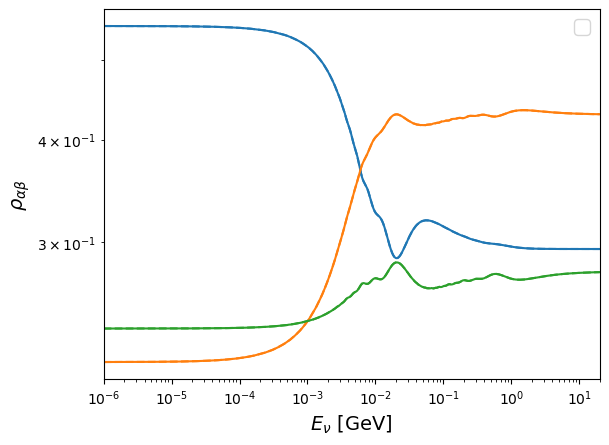

In [9]:
# Plot solar only
# plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
#             color="tab:blue")
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
#            color="tab:orange")
# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\tau\tau}$',
#            color="tab:green")


# Plot Earth + solar -- old
plt.loglog(Enuspace,abs(rho_earthceta1[:, 0,0]), ls='--', color="tab:blue" )
plt.loglog(Enuspace,abs(rho_earthceta1[:, 1,1]), ls='--', color="tab:orange" )
plt.loglog(Enuspace,abs(rho_earthceta1[:, 2,2]), ls='--', color="tab:green" )

# Plot Earth + solar -- vectorized
plt.loglog(Enuspace,abs(rho_earthceta2[:, 0,0]), ls='-',  color="tab:blue" )
plt.loglog(Enuspace,abs(rho_earthceta2[:, 1,1]), ls='-',  color="tab:orange" )
plt.loglog(Enuspace,abs(rho_earthceta2[:, 2,2]), ls='-',  color="tab:green" )



plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [9]:
np.shape(rho_earthceta1)

(400, 3, 3)

In [10]:
import tqdm as tqdm
from multiprocess import Pool

In [11]:
weights.sum()

np.float64(1.0001401477372538)

In [12]:
def rho_weighted_average(probevolution, rhosm, Enuspace, weights, angles):


    rho_ave = np.zeros(np.shape(rhosm), dtype=complex)
    
    for i in tqdm.tqdm(range(len(weights))):
        ceta = np.cos(angles[i])
        # evolve through earth
        rho_earth = probevolution.evolve_rhosolar(rhosm, Enuspace, ceta=ceta)
        rho_ave += weights[i] * rho_earth

    return rho_ave




def rho_weighted_average_parallel(probevolution, rhosm, Enuspace, weights, angles, nb_core=8):

    rho_ave = np.zeros(np.shape(rhosm), dtype=complex)

    # Arg list of cross sections
    args = []
    for i , w in enumerate(weights):
        ceta = np.cos(angles[i])
        args.append((w, ceta))

    def parallel_evolve(index):
        weight, ceta = args[index]
        rho_earth = probevolution.evolve_rhosolar(rhosm, Enuspace, ceta=ceta)
        return weight * rho_earth
    
    # Run the parallel evolution
    with Pool(nb_core) as pool:
        for result in tqdm.tqdm(pool.imap_unordered(parallel_evolve, range(len(args))), total=len(args), desc='Zenith angles'):
             rho_ave += result

    return rho_ave

In [13]:
# rho_ave = rho_weighted_average(PREMprob, density_sm, Enuspace, weights, angles)
rho_ave = rho_weighted_average_parallel(PREMprob, density_sm, Enuspace, weights, angles)

Zenith angles: 100%|██████████| 50/50 [00:49<00:00,  1.01it/s]


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

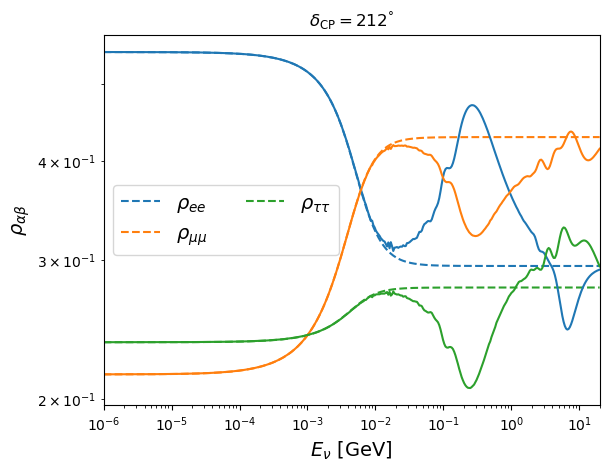

In [14]:
plt.loglog(Enuspace,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\tau\tau}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_ave[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_ave[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_ave[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.title(r"$\delta_{\rm CP}=212^\degree$")
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

## Run with old oscillation parameters

In [15]:
params_old = osc.osc_params_old

rho_sun2 = probs.DensityMatrixCalculator(sm_model, osc_params=params_old).density(Enuspace, '8B')
PREMprob2 = em.EarthProbEvolve(osc_params=params_old, model=sm_model, earthmodel=PREMmodel)



In [16]:
# rho_ave2 = rho_weighted_average(PREMprob2, rho_sun2, Enuspace, weights, angles)
rho_ave2 = rho_weighted_average_parallel(PREMprob2, rho_sun2, Enuspace, weights, angles)

Zenith angles: 100%|██████████| 50/50 [00:42<00:00,  1.18it/s]


Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

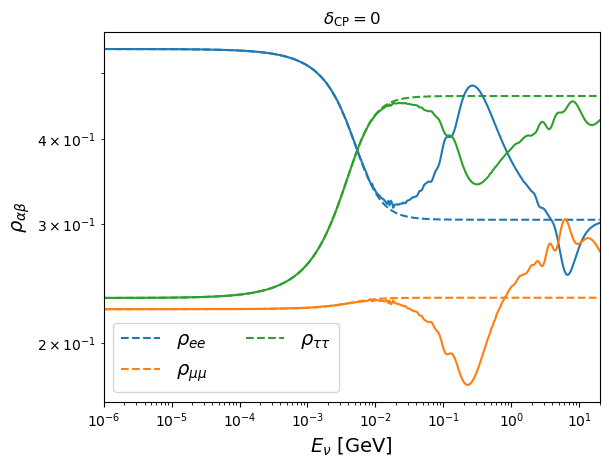

In [17]:
plt.loglog(Enuspace,abs(rho_sun2[:, 0,0]),  label=r'$\rho_{ee}$', 
            color="tab:blue", ls='--' )
plt.loglog(Enuspace,abs(rho_sun2[:, 1,1]),  label=r'$\rho_{\mu\mu}$',
           color="tab:orange", ls='--' )

plt.loglog(Enuspace,abs(rho_sun2[:, 2,2]),  label=r'$\rho_{\tau\tau}$',
           color="tab:green", ls='--' )

plt.loglog(Enuspace,abs(rho_ave2[:, 0,0]),  color="tab:blue" )


plt.loglog(Enuspace,abs(rho_ave2[:, 1,1]),  color="tab:orange" )


plt.loglog(Enuspace,abs(rho_ave2[:, 2,2]),  color="tab:green" )
# plt.loglog(Enuspace,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

# plt.loglog(Enuspace,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

#plt.loglog(Enuspace, Pee*, label=r'$P_{ee}$', ls=':', color="tab:blue" )


plt.xlim(xmin=1e-6, xmax=2.0e1)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.title(r"$\delta_{\rm CP}=0$")
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

In [18]:
angles < np.pi/2

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])